# 3.4 Binary classification

Binary classification assigns each sample to one of two classes. Our task in this chapter is a standard one in seismology: given a short window of seismogram data, decide whether it contains a seismic **event** (label 1) or only **noise** (label 0). Instead of raw waveforms, we work with four physical features computed from each window:

* `sta_lta`: the ratio of a short-term average amplitude to a long-term average amplitude. An impulsive arrival raises the short-term average and pushes the ratio well above 1. The distribution is heavy-tailed, spanning roughly 0.4 to 40.
* `kurtosis`: how impulsive the amplitude distribution is; spiky arrivals raise it.
* `spectral_centroid_hz`: the amplitude-weighted mean frequency of the window, roughly 0.2 to 24 Hz. Local events carry more high-frequency energy than ocean-generated microseism noise.
* `dominant_freq_hz`: the frequency of the spectral peak.

For the two-dimensional plots in this notebook we use `sta_lta` and `spectral_centroid_hz`: an event window tends to have both a high STA/LTA ratio and a high spectral centroid, while noise sits at low values of both.

## 1. Event versus noise data

We load a balanced set of 2000 windows, half events and half noise, from the course's synthetic data package.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlgeo_synth

df = mlgeo_synth.detector_features(n=2000, event_fraction=0.5, seed=42)
df.head()

,sta_lta,kurtosis,spectral_centroid_hz,dominant_freq_hz,label
0,0.792219,3.959336,1.982693,0.296883,0
1,9.776853,10.239785,8.493891,3.388564,1
2,2.257104,4.350056,0.480065,4.723088,0
3,20.654607,3.549487,8.102950,9.892636,1
4,1.770043,4.416638,1.006947,2.060523,0


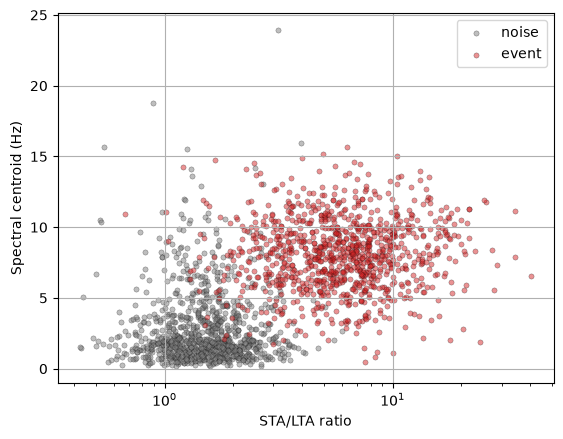

In [2]:
fig, ax = plt.subplots()
for label, name, color in [(0, "noise", "tab:gray"), (1, "event", "tab:red")]:
    sub = df[df["label"] == label]
    ax.scatter(sub["sta_lta"], sub["spectral_centroid_hz"],
               s=14, alpha=0.5, color=color, edgecolors="k", linewidths=0.3, label=name)
plt.xscale('log')
ax.set_xlabel("STA/LTA ratio")
ax.set_ylabel("Spectral centroid (Hz)")
ax.legend()
ax.grid(True)
plt.show()

The log-scaled x-axis already tells us how to build the feature matrix: taking the logarithm of a heavy-tailed ratio like STA/LTA is standard feature engineering, and we do it before handing the features to any model.

In [3]:
X = np.column_stack([np.log10(df["sta_lta"]), df["spectral_centroid_hz"]])
y = df["label"].values

Before any classifier, the baseline. The trivial predictor assigns every window to the most frequent class; on this balanced set that gives 0.5 accuracy, and every classifier below must beat it.

In [4]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent").fit(X, y)
print(f"Majority-class baseline accuracy: {baseline.score(X, y):.2f}")

Majority-class baseline accuracy: 0.50


We will start with the fundamental LDA.

In [5]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# define ML
clf = LinearDiscriminantAnalysis()

# normalize data.
X = StandardScaler().fit_transform(X)

# split data between train and test set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# Fit the model.
clf.fit(X_train, y_train)

# calculate the mean accuracy on the given test data and labels.
score = clf.score(X_test, y_test)
print("The mean accuracy on the given test and labels is %f" % score)

The mean accuracy on the given test and labels is 0.952500


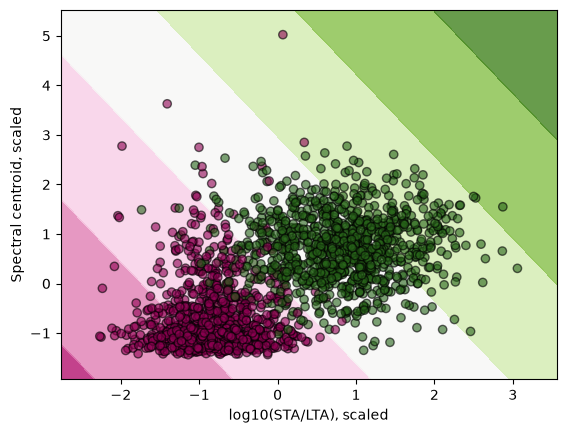

In [6]:
from sklearn.inspection import DecisionBoundaryDisplay
ax = plt.subplot()
# plot the decision boundary as a background
DecisionBoundaryDisplay.from_estimator(clf, X, cmap='PiYG', alpha=0.8, ax=ax, eps=0.5)
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='PiYG', alpha=0.6, edgecolors="k")
ax.set_xlabel("log10(STA/LTA), scaled")
ax.set_ylabel("Spectral centroid, scaled")
plt.show()

LDA draws a single straight line through the feature space. It does well here because the two classes are roughly separable by a line.

Let's try a different classifier: KNN.

In [7]:
from sklearn.neighbors import KNeighborsClassifier

# define ML
K = 5
clf = KNeighborsClassifier(K)

# split data between train and test set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# Fit the model.
clf.fit(X_train, y_train)

# calculate the mean accuracy on the given test data and labels.
score = clf.score(X_test, y_test)
print("The mean accuracy on the given test and labels is %f" % score)

The mean accuracy on the given test and labels is 0.960000


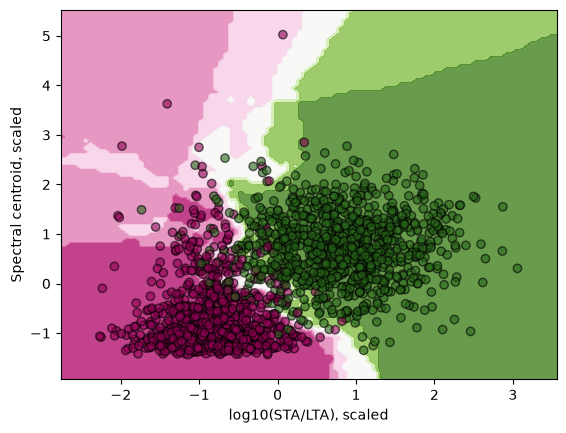

In [8]:
# plot the decision boundary as a background
ax = plt.subplot()
DecisionBoundaryDisplay.from_estimator(clf, X, cmap='PiYG', alpha=0.8, ax=ax, eps=0.5)
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='PiYG', alpha=0.6, edgecolors="k")
ax.set_xlabel("log10(STA/LTA), scaled")
ax.set_ylabel("Spectral centroid, scaled")
plt.show()

### Features with different physical units

Now we test what happens when we do **not** normalize the features. Our two features have different physical meanings: log-STA/LTA is dimensionless, the spectral centroid is a frequency. Suppose a colleague hands us the centroid in millihertz instead of hertz. Nothing physical has changed, but one axis is now numerically a thousand times larger.

The mean accuracy without scaling is 0.865000


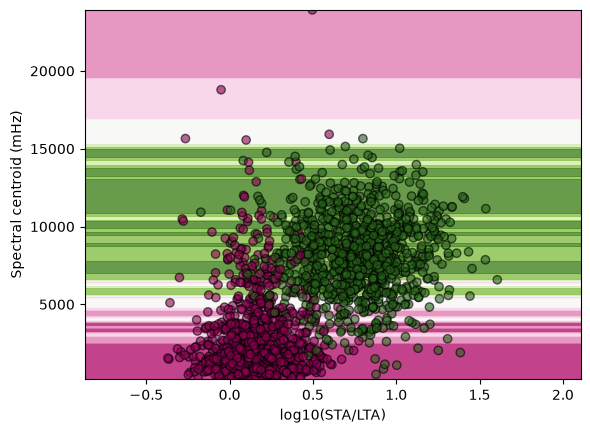

In [9]:
# rebuild the raw features, spectral centroid now in millihertz
X_raw = np.column_stack([np.log10(df["sta_lta"]), df["spectral_centroid_hz"] * 1000.0])

# same KNN, but no scaling this time
clf_raw = KNeighborsClassifier(K)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_raw, y, test_size=0.4, random_state=42)
clf_raw.fit(Xr_train, yr_train)
score = clf_raw.score(Xr_test, yr_test)
print("The mean accuracy without scaling is %f" % score)

# plot the decision boundary as a background
ax = plt.subplot()
DecisionBoundaryDisplay.from_estimator(clf_raw, X_raw, cmap='PiYG', alpha=0.8, ax=ax, eps=0.5)
ax.scatter(X_raw[:, 0], X_raw[:, 1], c=y, cmap='PiYG', alpha=0.6, edgecolors="k")
ax.set_xlabel("log10(STA/LTA)")
ax.set_ylabel("Spectral centroid (mHz)")
plt.show()

Accuracy drops and the decision boundary is now a set of horizontal bands: the classifier is effectively using the centroid alone. Distance-based classifiers see only numbers, not units. Euclidean distance in the (log-STA/LTA, millihertz) plane is dominated by the millihertz axis, so the STA/LTA information is ignored. Scaling with `StandardScaler` puts both features on equal footing, which is why we normalized before fitting.

## 2. Classifier Performance Metrics

In a binary classifier, we label one of the two classes as *positive*, the other class as *negative*. Let's consider *N* data samples.

| True Class \ predicted Class     | Positive            | Negative           | **Total** |
|  -------------  |  -----------------  |  --------------- | ----- |
| Positive        | True Positive   | False Negative | p     |
| Negative        | False Positive  | True Negative  | n     |
| **Total**       | p'                  | n'                 | N     |

In this example, there were originally a total of $p=FN+TP$ positive labels and $n=FP+TN$ negative levels. We ended up with $p'=TP+FP$ predicted as positive and $n'=FN+TN$ predicted as negative.

**True positive TP**: the number of data predicted as *positive* that were originally *positive*.

**True negative TN**: the number of data predicted as *negative* that were originally *negative*.

**False positive FP**: the number of data predicted as *positive* but that were originally *negative*.

**False negative FN**: the number of data predicted as *negative* that were originally *positive*.

**Confusion matrix:**
Count the instances that an element of class *A* is classified in class *B*. A 2-class confusion matrix is:

$ C = \begin{array}{|cc|} TP & FN \\ FP  & TN \end{array}$

The confusion matrix can be extended for a multi-class classification and the matrix is KxK instead of 2x2. The best confusion matrix is one that is close to identity, with little off diagonal terms.

**Other model performance metrics**
Model peformance can be assessed with the following:
* **Error** : the fraction of the data that was misclassified

    $err = \frac{FP+FN}{N}$  -> 0
* **Accuracy**: the fraction of the data that was correctly classified:

    $acc = \frac{TP+TN}{N} = 1 - err $ --> 1

* **TP-rate**: the ratio of samples predicted in the *positive* class that are correctly classified:

    $TPR = \frac{TP}{TP+FN}$ --> 1

    This ratio is also the **recall** value or **sensitivity**.

* **TN-rate**: the ratio of samples predicted in the *negative* class that are correctly classified:

    $TNR = \frac{TN}{TN+FP}$ --> 1

    This ratio is also the **specificity**.

* **Precision**: the ratio of samples predicted in the *positive* class that were indeed *positive* to the total number of samples predicted as *positive*.

    $pr = \frac{TP}{TP+FP}$ --> 1

* **F1 score**:

    $F_1 = \frac{2}{(1/ precision + 1/recall)} = \frac{TP}{TP + (FN+FP)/2} $ --> 1.


The harmonic mean of the F1 scores gives more weight to low values. F1 score is thus high if both recall and precision are high.

***How do precision and recall co-vary?***

In [10]:
def returnPrecisionAndRecall(TP, FP, TN, FN):
    precision = TP / (TP + FP) if (TP + FP) else 0
    recall = TP / (TP + FN) if (TP + FN) else 0
    return {'precision': precision, 'recall': recall}

# Okay, set how many true and false values are in the original dataset

actualTrueValues = 10
actualFalseValues = 10

sumValues = actualTrueValues + actualFalseValues

precisionRecallCollector = []

# Now, run a set of simulations

for n in range(5000):
    TP = 0
    FP = 0
    TN = 0
    FN = 0
    # Begin by randomly setting the total number of true values returned
    totalTrue = np.random.randint(0, high=sumValues)
    # The total number of false values is sumValues - totalTrue
    totalFalse = sumValues - totalTrue
    # Partition totalTrue and totalFalse into TP, FP and TN, FN, respectively
    if totalTrue != 0:
        TP = np.random.randint(0, high=totalTrue)
        FP = totalTrue - TP
    if totalFalse != 0:
        TN = np.random.randint(0, high=totalFalse)
        FN = totalFalse - TN
    thisPandR = returnPrecisionAndRecall(TP, FP, TN, FN)
    precisionRecallCollector.append([thisPandR['precision'], thisPandR['recall']])

Text(0, 0.5, 'Recall')

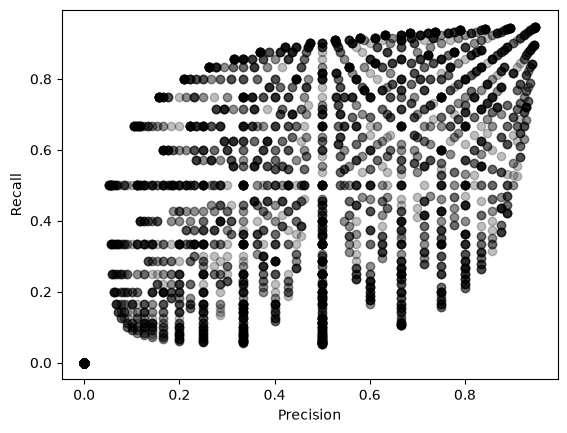

In [11]:
pAndRArray = np.asarray(precisionRecallCollector)
plt.scatter(pAndRArray[:,0], pAndRArray[:,1], color='k', alpha=0.25)
plt.xlabel('Precision')
plt.ylabel('Recall')

From above, we see that a wide range of behavior between precision and recall can be expected. It is not because a classifier might do well in predicting one class than it does predicting the other class. This demonstrates the important of reporting both metrics.

Let's print these measures for our scaled KNN classifier, evaluated on the test set, using scikit-learn.

In [12]:
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score

# Fit the model.
y_test_pred=clf.predict(X_test)

print("confusion matrix")
print(confusion_matrix(y_test,y_test_pred))
print("precison, recall")
print(precision_score(y_test,y_test_pred),recall_score(y_test,y_test_pred))
print("F1 score")
print(f1_score(y_test,y_test_pred))

confusion matrix


[[384  12]
 [ 20 384]]
precison, recall
0.9696969696969697 0.9504950495049505
F1 score
0.96


A complete well-formatted report of the performance can be called using the function ``classification_report``:

In [13]:
from sklearn.metrics import classification_report
print(f"Classification report for classifier {clf}:\n"
      f"{classification_report(y_test, y_test_pred)}\n")

Classification report for classifier KNeighborsClassifier():
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       396
           1       0.97      0.95      0.96       404

    accuracy                           0.96       800
   macro avg       0.96      0.96      0.96       800
weighted avg       0.96      0.96      0.96       800




**Precision and recall trade off**: increasing precision reduces recall.

$precision = \frac{TP}{TP+FP}$

$recall = \frac{TP}{TP+FN}$


The classifier uses a *threshold* value to decide whether a data belongs to a class. Increasing the threshold gives higher precision score, decreasing the thresholds gives higher recall scores. Let's look at the various score values.

**Receiver Operating Characteristics ROC**

It plots the true positive rate against the false positive rate.
The ROC curve is visual, but we can quantify the classifier performance using the *area under the curve* (aka AUC). Ideally, AUC is 1.

![ROC curve](roc-curve-v2-glassbox.png)

[source: https://commons.wikimedia.org/wiki/File:Roc-draft-xkcd-style.svg]

We compute the curve on the **test set**: earlier editions of this book plotted the training-set ROC, and that flatters the model.

In [14]:
y_scores = clf.predict_proba(X_test)
print(y_scores[:5])

[[1.  0. ]
 [1.  0. ]
 [0.  1. ]
 [0.8 0.2]
 [0.  1. ]]


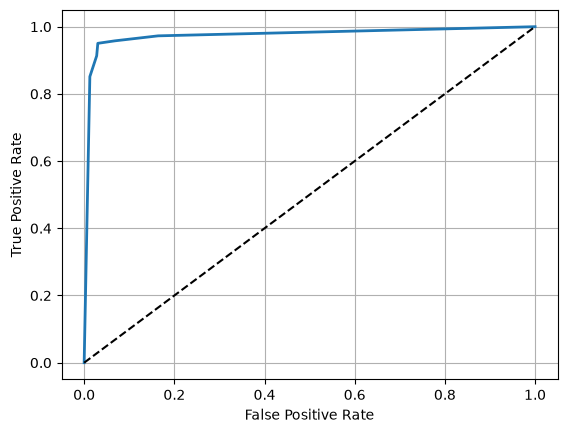

In [15]:
from sklearn.metrics import roc_curve

fpr,tpr,thresholds=roc_curve(y_test,y_scores[:,1])
plt.plot(fpr,tpr,linewidth=2);plt.grid(True)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.plot([0,1],[0,1],'k--')

We now explore the different classifiers packaged in scikit-learn. We can systematically test their performance and save the precision, recall, and F1 scores.

```{admonition} Attribution
:class: note
The classifier list below is adapted from the scikit-learn classifier comparison example by Gaël Varoquaux and Andreas Müller (BSD 3-clause license).
```

A word of caution on one entry: `GaussianProcessClassifier` training scales as $O(n^3)$ with the number of samples. It is fine here at $n=2000$, but it is a trap on real detection catalogs, which routinely hold $10^5$ to $10^6$ windows.

In [16]:
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# define models
names = [
    "Nearest Neighbors",
    "Linear SVM",
    "RBF SVM",
    "Gaussian Process",
    "Decision Tree",
    "Random Forest",
    "AdaBoost",
    "Naive Bayes",
    "QDA",
]

classifiers = [
    KNeighborsClassifier(7),
    SVC(kernel="linear", C=0.025),
    SVC(gamma=2, C=1),
    GaussianProcessClassifier(1.0 * RBF(1.0)),
    DecisionTreeClassifier(max_depth=5),
    RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1),
    AdaBoostClassifier(),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
]

## 3. Model exploration

* Explore How each of these models perform on the synthetic data.

* Save in an array the precision, recall, F1 score values.

* Find the best performing model

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
pre=np.zeros(len(classifiers))
rec=np.zeros(len(classifiers))
f1=np.zeros(len(classifiers))

for ii,iclass in enumerate(classifiers):
    iclass.fit(X_train, y_train)
    y_test_pred=iclass.predict(X_test)
    pre[ii] =precision_score(y_test,y_test_pred)
    rec[ii] =recall_score(y_test,y_test_pred)
    f1[ii] =f1_score(y_test,y_test_pred)

df_scores=pd.DataFrame({'CLF name':names,'precision':pre,'recall':rec,'f1_score':f1})
print(df_scores)

            CLF name  precision    recall  f1_score
0  Nearest Neighbors   0.969543  0.945545  0.957393
1         Linear SVM   0.969309  0.938119  0.953459
2            RBF SVM   0.967089  0.945545  0.956195
3   Gaussian Process   0.971939  0.943069  0.957286
4      Decision Tree   0.966837  0.938119  0.952261
5      Random Forest   0.962312  0.948020  0.955112
6           AdaBoost   0.959900  0.948020  0.953923
7        Naive Bayes   0.966921  0.940594  0.953576
8                QDA   0.966921  0.940594  0.953576


## Imbalanced detection: when accuracy stops meaning anything

The balanced set above was a convenient classroom fiction. On a real station, event windows are rare: most of the day is noise. We now draw 5000 windows with an event fraction of 2 percent, about 100 events among 4900 noise windows — a 1:50 imbalance. Same features, same log transform, same scaling. The split is *stratified* so that the rare class keeps the same proportion in train and test.

In [18]:
df_imb = mlgeo_synth.detector_features(n=5000, event_fraction=0.02, seed=42)
print(df_imb["label"].value_counts())

X_imb = np.column_stack([np.log10(df_imb["sta_lta"]), df_imb["spectral_centroid_hz"]])
y_imb = df_imb["label"].values
X_imb = StandardScaler().fit_transform(X_imb)

Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    X_imb, y_imb, stratify=y_imb, test_size=0.4, random_state=42
)

baseline = DummyClassifier(strategy="most_frequent").fit(Xi_train, yi_train)
print(f"Majority-class baseline accuracy: {baseline.score(Xi_test, yi_test):.3f}")

label
0    4900
1     100
Name: count, dtype: int64
Majority-class baseline accuracy: 0.980


The trivial predictor that never declares an event already scores 0.98. Accuracy is now useless as a metric. Let's train two real classifiers and look at the metrics that matter for the event class.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

logreg = LogisticRegression().fit(Xi_train, yi_train)
forest = RandomForestClassifier(n_estimators=100, random_state=42).fit(Xi_train, yi_train)

for name, model in [("Logistic regression", logreg), ("Random forest", forest)]:
    yp = model.predict(Xi_test)
    print(name)
    print(f"  accuracy         : {accuracy_score(yi_test, yp):.3f}")
    print(f"  precision (event): {precision_score(yi_test, yp):.3f}")
    print(f"  recall (event)   : {recall_score(yi_test, yp):.3f}")
    print(f"  F1 (event)       : {f1_score(yi_test, yp):.3f}")

Logistic regression
  accuracy         : 0.992
  precision (event): 0.929
  recall (event)   : 0.650
  F1 (event)       : 0.765
Random forest
  accuracy         : 0.992
  precision (event): 0.853
  recall (event)   : 0.725
  F1 (event)       : 0.784


Both models beat the baseline accuracy by less than one percentage point, yet they miss roughly a third of the events. Recall on the event class is the number the analyst cares about: it counts the earthquakes the detector actually catches. The trade-off is operational. A detector tuned for high recall floods the analyst with false triggers to review; a detector tuned for high precision keeps the trigger list clean but misses small events. Where to sit on that curve is a decision about analyst time and scientific cost, not a modeling detail.

We can see the whole trade-off at once by plotting the ROC curve and the precision-recall curve side by side.

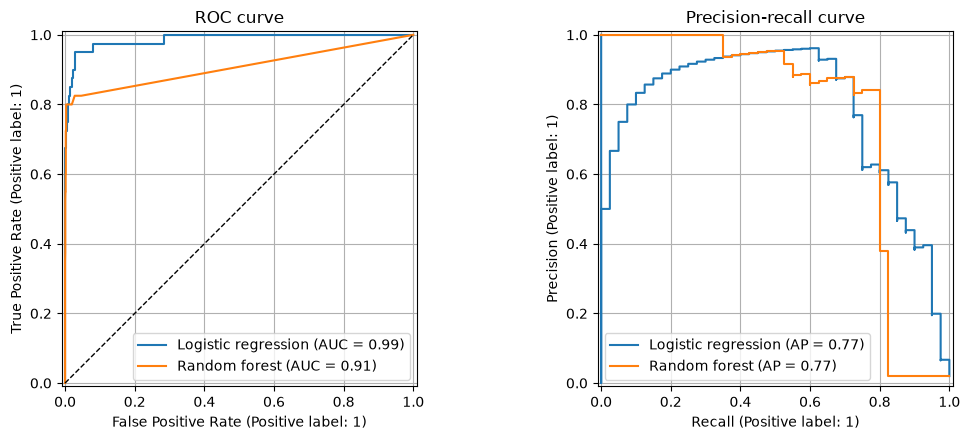

In [20]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
for name, model in [("Logistic regression", logreg), ("Random forest", forest)]:
    RocCurveDisplay.from_estimator(model, Xi_test, yi_test, ax=ax1, name=name)
    PrecisionRecallDisplay.from_estimator(model, Xi_test, yi_test, ax=ax2, name=name)
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax1.set_title("ROC curve")
ax2.set_title("Precision-recall curve")
ax1.grid(True)
ax2.grid(True)
plt.tight_layout()
plt.show()

The ROC curve looks excellent, and that is exactly the problem. With a 1:50 imbalance the false-positive **rate** divides by the 2940 noise windows, so it stays tiny even when false positives outnumber true detections. The precision-recall curve divides by the number of *predicted* positives instead, so it tracks the analyst's actual workload: it drops as soon as the trigger list fills with noise. When the positive class is rare, read the PR curve, not the ROC.

## Closing

The choice of metric is a design decision, not an afterthought. It encodes the operational cost of each error type: a missed event costs science, a false trigger costs analyst time. Decide what each error costs in your application, pick the metric that prices it, and only then compare models.